In [110]:
import pandas as pd
import datasets

In [111]:
sciq = pd.read_csv('/content/sciq_clean.csv')
arc = pd.read_csv('/content/arc_clean.csv')
mmlu = pd.read_csv('/content/mmlu_clean.csv')

In [112]:
combined_df = pd.concat([sciq, arc, mmlu], ignore_index=True)
display(combined_df.head())

,dataset_source,text,answer_key
0,SciQ,"Question: When atoms gain or lose electrons, t...",D
1,SciQ,"Question: What control reproductive cycles, wh...",B
2,SciQ,Question: Wich disorder arises when defective ...,B
3,SciQ,Question: Because core electrons are closer to...,B
4,SciQ,"Question: ""endocrine"" and ""exocrine"" are two t...",D


In [113]:
combined_df= combined_df.sample(frac=1, random_state=42).reset_index(drop=True)
display(combined_df.head())

,dataset_source,text,answer_key
0,SciQ,Question: The joints of the carpal bones in th...,B
1,MMLU,Question: Trish’s resting heart rate is 50 bea...,B
2,MMLU,"Question: A newspaper company sold 179,912 new...",D
3,SciQ,Question: Tuna have been shown to contain high...,C
4,MMLU,Question: Identify the Brønsted-Lowry conjugat...,C


In [114]:
combined_df.shape

(5116, 3)

In [115]:
combined_df.describe()

,dataset_source,text,answer_key
count,5116,5116,5116
unique,3,5109,4
top,SciQ,Question: A rod measures 1.00 m in its rest sy...,D
freq,2000,2,1316


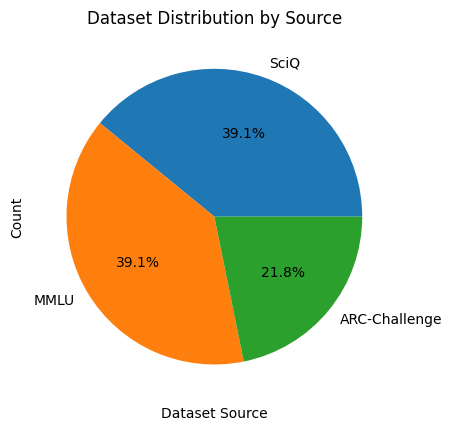

In [116]:
import matplotlib.pyplot as plt
import seaborn as sns

combined_df['dataset_source'].value_counts().plot.pie(autopct='%1.1f%%')
plt.xticks(rotation=90)
plt.title('Dataset Distribution by Source')
plt.xlabel('Dataset Source')
plt.ylabel('Count')
plt.show()

In [117]:
import warnings
warnings.filterwarnings('ignore')

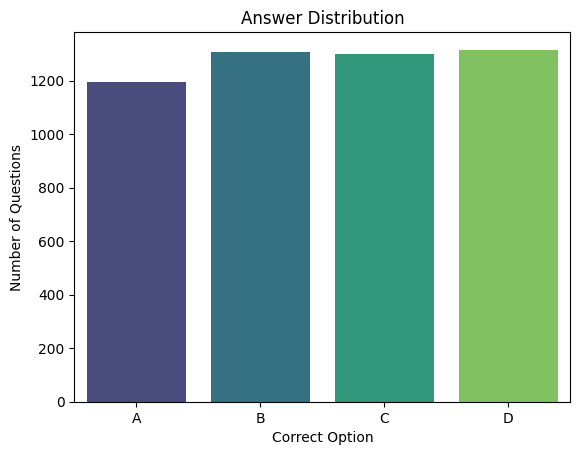

In [118]:
sns.countplot(data=combined_df, x='answer_key', order=['A', 'B', 'C', 'D'], palette='viridis')
plt.title('Answer Distribution')
plt.xlabel('Correct Option')
plt.ylabel('Number of Questions')
plt.show()

In [119]:
combined_df.to_csv('combined_data.csv')

In [120]:
train_df = combined_df.sample(frac=0.8, random_state=42)
test_df = combined_df.drop(train_df.index)

In [121]:
from datasets import Dataset
hf_train = Dataset.from_pandas(train_df)
hf_test = Dataset.from_pandas(test_df)
print("Hugging Face Train Dataset:")
display(hf_train[0])
print("\nHugging Face Test Dataset:")
display(hf_test[0])

Hugging Face Train Dataset:


{'dataset_source': 'MMLU',
 'text': 'Question: Find the quotient of 2.16 ÷ 0.06.\n\nA. 3.6\nB. 36\nC. 0.01272\nD. 12.72\n\nAnswer: B',
 'answer_key': 'B',
 '__index_level_0__': 530}


Hugging Face Test Dataset:


{'dataset_source': 'SciQ',
 'text': 'Question: Tuna have been shown to contain high levels of what metal?\n\nA. titanium\nB. cadmium\nC. mercury\nD. iron\n\nAnswer: C',
 'answer_key': 'C',
 '__index_level_0__': 3}

In [122]:
import os
os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"

In [123]:
!pip install -q -U transformers accelerate bitsandbytes

In [124]:
import os
os.environ['LD_LIBRARY_PATH'] += ':/usr/local/cuda-13.0/lib64'

In [125]:
from google.colab import userdata
from huggingface_hub import login

In [126]:
hf_token = userdata.get('HF_TOKEN')
login(hf_token)
print("Authenticated successfully!")

Authenticated successfully!


In [127]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
model_id = "google/gemma-2b"
bnb_config = BitsAndBytesConfig(
    load_in_4bit = True,
    bnb_4bit_quant_type = "nf4", # a specific math algo for qlora.
    bnb_4bit_compute_dtype=torch.float16
)

In [128]:
tokenizer = AutoTokenizer.from_pretrained(model_id)

In [129]:
print("Downloading Gemma 2B")
model = AutoModelForCausalLM.from_pretrained(model_id, quantization_config=bnb_config, device_map="auto")
print("Sucess! The engine is running")

Loading weights:   0%|          | 0/164 [00:00<?, ?it/s]

Sucess! The engine is running


In [130]:
import warnings
warnings.filterwarnings('ignore')

In [131]:
from transformers import pipeline
generator = pipeline("text-generation", model=model, tokenizer=tokenizer)
prompt = """Question: What is the main function of red blood cells?
Answer:"""
result = generator(prompt, max_new_tokens=50)
print("\n--- AI TEST RESPONSE ---")
print(result[0]['generated_text'])

[transformers] Both `max_new_tokens` (=50) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--- AI TEST RESPONSE ---
Question: What is the main function of red blood cells?
Answer:
Red blood cells are the main component of the blood. They have a biconcave shape so that they can easily take up oxygen from the air in the alveoli. The biconcave shape also allows them to fit as much as possible in


In [132]:
correct_answers = 0
total_questions = 100
print(f"Testing baseline Gemma 2B on {total_questions} questions...")

Testing baseline Gemma 2B on 100 questions...


In [133]:
import re

In [134]:
for i in range(total_questions):
    raw_text = hf_test[i]['text']
    question_only = raw_text.split("Answer:")[0] + "Answer:"
    question_text = question_only.strip()
    correct_answer = hf_test[i]['answer_key'].strip().upper()
    inputs = tokenizer(question_text, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=2, pad_token_id=tokenizer.eos_token_id, temperature=0.0)
    decoded = tokenizer.decode(outputs[0], skip_special_tokens=True)
    clean_text = decoded.split("Answer:")[-1].upper().replace("OPTION", "")
    match = re.search(r'[ABCD]', clean_text)
    last_letter = match.group(0) if match else "X"
    if last_letter == correct_answer:
        correct_answers += 1
    if (i + 1) % 10 == 0:
        print(f"Graded {i+1}/{total_questions} questions...")

Graded 10/100 questions...
Graded 20/100 questions...
Graded 30/100 questions...
Graded 40/100 questions...
Graded 50/100 questions...
Graded 60/100 questions...
Graded 70/100 questions...
Graded 80/100 questions...
Graded 90/100 questions...
Graded 100/100 questions...


In [135]:
baseline_accuracy = (correct_answers / total_questions) * 100
print("BASELINE GEMMA 2B RESULTS")
print(f"\tCorrect : {correct_answers} / {total_questions}")
print(f"\tAccuracy: {baseline_accuracy:.2f}%")


BASELINE GEMMA 2B RESULTS
	Correct : 39 / 100
	Accuracy: 39.00%


In [136]:
from google.colab import drive
drive.mount('/content/drive')
import json
path = "/content/drive/MyDrive/Colab Notebooks/start1.ipynb"
with open(path, "r", encoding="utf-8") as f:
    nb = json.load(f)
nb.get("metadata", {}).pop("widgets", None)
for cell in nb.get("cells", []):
    cell.get("metadata", {}).pop("widgets", None)
with open(path, "w", encoding="utf-8") as f:
    json.dump(nb, f, ensure_ascii=False, indent=1)
print("Fixed notebook metadata!")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Fixed notebook metadata!


In [138]:
import json
path = "/content/drive/MyDrive/Colab Notebooks/start1.ipynb"

try:
    with open(path, "r", encoding="utf-8") as f:
        nb = json.load(f)
    if "metadata" in nb and "widgets" in nb["metadata"]:
        del nb["metadata"]["widgets"]
        print("✅ Cleaned top-level metadata.")

    cells_fixed = 0
    for cell in nb.get("cells", []):
        if "metadata" in cell and "widgets" in cell["metadata"]:
            del cell["metadata"]["widgets"]
            cells_fixed += 1

        if "outputs" in cell:
            clean_outputs = []
            for out in cell["outputs"]:
                if "data" in out and "application/vnd.jupyter.widget-view+json" in out["data"]:
                    cells_fixed += 1
                    continue
                clean_outputs.append(out)
            cell["outputs"] = clean_outputs
    with open(path, "w", encoding="utf-8") as f:
        json.dump(nb, f, ensure_ascii=False, indent=1)

    print(f"✅ Deep clean complete! Removed {cells_fixed} hidden widget bugs. You are clear to upload.")

except FileNotFoundError:
    print("❌ ERROR: Could not find the file. Check the path!")

✅ Cleaned top-level metadata.
✅ Deep clean complete! Removed 1 hidden widget bugs. You are clear to upload.
